# Unsupervised Learning — Clustering Accidents into Profiles

**Part 2 of the Phase 2 Portfolio Project.**

**Authors:** Leomary Rodriguez & Oluwafikunayomi Adeniji

## What we did

The brief suggested that "the weather and infrastructure columns support clustering to find
distinct accident profiles", so that is the question we set out to answer: do UK road accidents
fall into a small number of recognisable *types*, defined purely by the circumstances they
happened in?

We grouped accidents by road type, speed limit, light, weather, time of day and junction layout,
then checked afterwards what share of each group turned out to be fatal. The resulting cluster
labels are handed to the supervised modelling pair as a feature in Section 9.

## The rule we held to

**We never let `Accident_Severity` into the clustering.** We clustered on circumstances only, and
looked at severity afterwards.

We were deliberate about this for two reasons. If severity had gone into the clustering, the
clusters would simply have rediscovered severity, and the feature we pass to the supervised model
would leak the answer, in other words, their model would look excellent and mean nothing. Second, keeping severity
out is what makes the result worth having. A cluster built only from road and weather conditions
that turns out to be four times as deadly as another is telling us something real about which
conditions kill people.

## What we expected going in

Only 1.29% of accidents in this dataset are fatal, so we knew every cluster would be overwhelmingly
Slight. We were not looking for a cluster of fatal crashes. We were looking for the fatal *rate* to
differ meaningfully between clusters, which is a lower bar and a more honest one.

## Section 0 — Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

## Section 1 — Load the cleaned data

We read the shared cleaned file, the same one [`main_eda.ipynb`](../notebooks/main_eda.ipynb) uses, so our results are directly
comparable with the EDA findings. Setup instructions are in `data/README.md` if the file isn't on
your machine yet.

We load only the columns we need — the full accident file has 36 and we use 12.

In [14]:
FEATURES_NUMERIC = ['Speed_limit', 'Number_of_Vehicles', 'Hour']
FEATURES_CATEGORICAL = ['Road_Type', 'Light_Conditions', 'Weather_Conditions',
                        'Road_Surface_Conditions', 'Urban_or_Rural_Area',
                        'Junction_Detail', 'Day_of_Week']
FEATURES = FEATURES_NUMERIC + FEATURES_CATEGORICAL

accidents = pd.read_csv('../data/preprocessed/accidents_clean.csv', low_memory=False,
                        usecols=['Accident_Index', 'Accident_Severity', 'Year'] + FEATURES)

print('rows:', f'{len(accidents):,}')
print('years:', accidents['Year'].min(), '-', accidents['Year'].max())

rows: 2,047,256
years: 2005 - 2017


## Section 2 — Choosing the features

Every feature we picked describes **the situation the accident happened in**, never its outcome.

| Feature | Why we included it |
|---|---|
| `Speed_limit` | The strongest environmental signal in our EDA |
| `Number_of_Vehicles` | Separates single-vehicle from multi-vehicle collisions |
| `Hour` | Rush hour and night driving are different situations |
| `Road_Type` | Roundabouts, dual and single carriageways behave very differently |
| `Light_Conditions` | Daylight against unlit darkness was a 4x difference in the EDA |
| `Weather_Conditions` | Directly suggested by the brief |
| `Road_Surface_Conditions` | Wet, dry, ice and snow |
| `Urban_or_Rural_Area` | Town roads against country roads |
| `Junction_Detail` | Junction layout, which the EDA showed matters a lot |
| `Day_of_Week` | Weekday and weekend traffic differ |

**What we left out, and why:**

- `Accident_Severity` and `Number_of_Casualties` are outcomes. Including either causes the leakage
  problem described above.
- `Junction_Control` (37% missing) and `Journey_Purpose_of_Driver` (45%+ missing) are too
  incomplete — we would be clustering on absence as much as on content.
- `Local_Authority_(District)` and `LSOA_of_Accident_Location` have hundreds of levels each.
  One-hot encoding them would swamp every other feature.
- `Latitude` and `Longitude` would turn the clusters into a map of Britain rather than a
  description of driving conditions.

**Missing values.** We dropped rows missing any chosen feature rather than imputing. It costs about
2.7% of the data, small enough not to skew the result, and it avoids inventing conditions that were
never recorded. Note that the accident file covers 2005–2017, so the 2004 problem we found during
EDA does not apply here — that was confined to the vehicle file.

In [15]:
before = len(accidents)
accidents = accidents.dropna(subset=FEATURES).copy()

print(f'dropped {before - len(accidents):,} incomplete rows ({(before-len(accidents))/before:.1%})')
print(f'remaining: {len(accidents):,}')
print()
print('overall fatal rate: {:.2%}'.format((accidents['Accident_Severity'] == 'Fatal').mean()))

dropped 55,699 incomplete rows (2.7%)
remaining: 1,991,557

overall fatal rate: 1.30%


## Section 3 — Train/test split

**We agreed this split with the supervised modelling pair before running anything below.** Both
halves of Part 2 use the same split and the same seed. If our cluster labels were built on a
different split than their model trains on, the labels would not line up and one of us would have
to redo the work.

We stratified on severity. Fatal accidents are only 1.29% of the data, so a plain random split can
easily leave the test set with a noticeably different fatal rate by chance.

We fit the clustering on the **training set only**, then assign clusters to the test set with
`.predict()`. Strictly the clustering never sees the labels, so fitting on everything would not be
leakage in the usual sense — but keeping the discipline means the supervised pair can treat
`cluster_id` exactly like any other engineered feature, with no special caveats.

In [16]:
SPLIT_SEED = 42        # <-- must match the supervised notebook
TEST_SIZE = 0.2

train, test = train_test_split(
    accidents, test_size=TEST_SIZE, random_state=SPLIT_SEED,
    stratify=accidents['Accident_Severity'])

print(f'train: {len(train):,}   fatal {(train["Accident_Severity"]=="Fatal").mean():.2%}')
print(f'test:  {len(test):,}   fatal {(test["Accident_Severity"]=="Fatal").mean():.2%}')

train: 1,593,245   fatal 1.30%
test:  398,312   fatal 1.30%


## Section 4 — Sample and encode

**Why we sampled.** The training set is roughly 1.6 million rows. KMeans itself would cope, but the
silhouette score in Section 5 compares every point against every other, so it does not scale to
that size. We fit on a random 150,000-row sample — far more than enough for stable clusters on ten
features — then apply the fitted model to all 2 million rows in Section 6.

**Why we scaled the numeric columns.** `Speed_limit` runs up to 70 while the one-hot columns are 0
or 1. Left unscaled, KMeans would treat a 10 mph difference as more important than the difference
between broad daylight and an unlit road, purely because of the units involved.

`drop='first'` removes one redundant column per feature, since the last category is implied by the
others being zero.

In [17]:
SAMPLE_SIZE = 150_000
SEED = 42

train_sample = train.sample(SAMPLE_SIZE, random_state=SEED)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUMERIC),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), FEATURES_CATEGORICAL),
])

X_sample = preprocessor.fit_transform(train_sample[FEATURES])

print('sample shape after encoding:', X_sample.shape)
print('(rows, features) - features grew because each category became its own column')

sample shape after encoding: (150000, 38)
(rows, features) - features grew because each category became its own column


## Section 5 — Choosing how many clusters

We used the two standard checks:

- **Elbow / inertia** — how tightly points sit around their cluster centre. It always falls as k
  rises, so what matters is the bend where extra clusters stop buying much.
- **Silhouette** — how cleanly separated the clusters are, from -1 to 1. We compute it on a
  10,000-row subsample because it compares every pair of points.

We expected modest silhouette scores. One-hot encoded categorical data does not form neat spherical
blobs, so values around 0.1–0.3 are normal here and do not mean the clustering has failed.

k= 2  inertia=     711,061  silhouette=0.229
k= 3  inertia=     634,063  silhouette=0.142
k= 4  inertia=     585,459  silhouette=0.147
k= 5  inertia=     550,052  silhouette=0.133
k= 6  inertia=     528,938  silhouette=0.127
k= 7  inertia=     499,697  silhouette=0.128
k= 8  inertia=     477,445  silhouette=0.125
k= 9  inertia=     463,943  silhouette=0.126
k=10  inertia=     451,895  silhouette=0.131


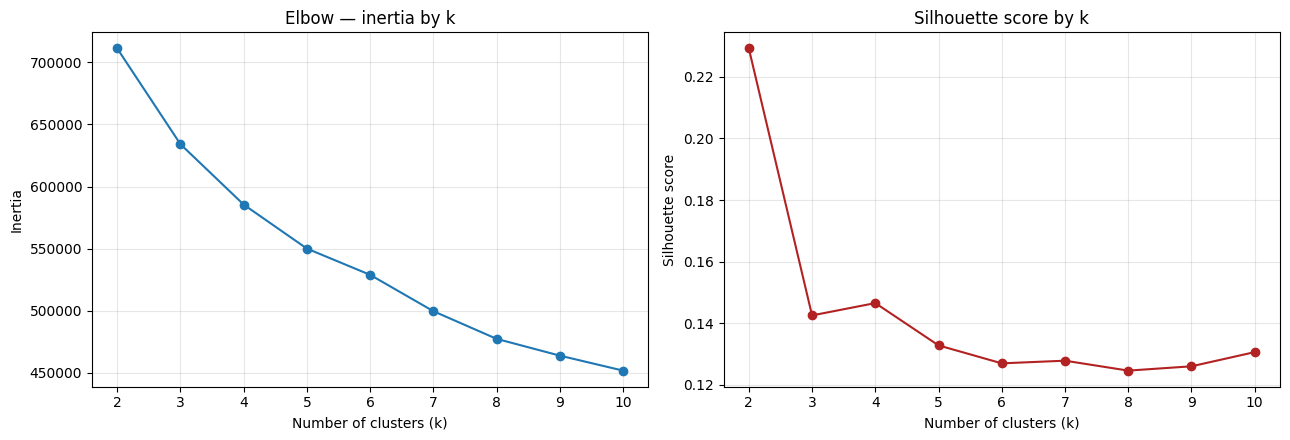

In [18]:
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=5)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels, sample_size=10_000, random_state=SEED))
    print(f'k={k:2}  inertia={km.inertia_:12,.0f}  silhouette={silhouettes[-1]:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(list(k_range), inertias, '-o')
ax[0].set_title('Elbow — inertia by k'); ax[0].set_xlabel('Number of clusters (k)'); ax[0].set_ylabel('Inertia')
ax[1].plot(list(k_range), silhouettes, '-o', color='firebrick')
ax[1].set_title('Silhouette score by k'); ax[1].set_xlabel('Number of clusters (k)'); ax[1].set_ylabel('Silhouette score')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [19]:
# The silhouette score above says k=2. Before accepting that, we checked what each k actually
# produces: if an extra cluster splits a group into two halves with the same fatal rate, it has
# described the same situation twice and bought us nothing.
X_all = preprocessor.transform(accidents[FEATURES])
is_fatal = (accidents['Accident_Severity'] == 'Fatal').values

comparison = []
for k in range(2, 7):
    labels_k = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_sample).predict(X_all)
    fatal_k = (pd.Series(is_fatal).groupby(labels_k).mean() * 100).sort_values()
    comparison.append({
        'k': k,
        'lowest fatal %': round(fatal_k.iloc[0], 2),
        'highest fatal %': round(fatal_k.iloc[-1], 2),
        'spread': f'{fatal_k.iloc[-1] / fatal_k.iloc[0]:.1f}x',
        'every cluster, lowest to highest': ', '.join(f'{v:.2f}' for v in fatal_k),
    })

pd.DataFrame(comparison).set_index('k')

,lowest fatal %,highest fatal %,spread,"every cluster, lowest to highest"
k,,,,
2,0.76,2.81,3.7x,"0.76, 2.81"
3,0.74,2.81,3.8x,"0.74, 0.84, 2.81"
4,0.72,2.66,3.7x,"0.72, 0.85, 1.90, 2.66"
5,0.57,2.65,4.6x,"0.57, 0.98, 1.03, 1.94, 2.65"
6,0.57,2.83,5.0x,"0.57, 0.93, 0.99, 1.69, 2.62, 2.83"


### Our choice: k = 5

The two checks disagreed, so we had to decide between them.

The silhouette score is highest at **k=2** (0.229) and falls to 0.133 by k=5. But k=2 splits the
data into "urban" and "rural" and nothing else — a distinction we already have as a column, and one
the EDA had already made. A high score for a result we could have reached with a single `groupby`
is not a useful result. Silhouette measures how cleanly separated clusters are, not how much they
tell us, and on one-hot encoded data it will almost always favour fewer clusters.

So we judged each k against a different question, which the cell above tests directly: **does each
additional cluster describe a distinct situation that also carries a distinct level of risk?**

| k | Fatal spread | What the extra cluster added |
|---|---|---|
| 2 | 3.7x | Urban against rural — a column we already had |
| 3 | 3.8x | Split urban by time, but fatal rates were 0.84% and 0.74% — the same risk twice |
| 4 | 3.7x | Isolated multi-vehicle collisions (3.4 vehicles average, 1.90% fatal) — genuinely new |
| **5** | **4.6x** | Separated night-time urban driving (1.03%), and morning and afternoon urban accidents finally differ properly (0.98% against 0.57%) |
| 6 | 5.0x | Split rural roads into morning and afternoon, 2.62% and 2.83% — the same risk twice again |

On that test k=3 and k=6 both fail: the cluster they add describes a situation no more or less
dangerous than the one it split from. k=4 and k=5 both pass, and k=5 passes twice over.

**We chose k=5** — five profiles that can each be named in plain English, with fatal rates from
0.57% to 2.65%, a spread of 4.6x.

We are choosing interpretability over the silhouette score deliberately, and we want to be explicit
that this is a judgement call rather than something the metrics decided for us. Our reasoning is
that the higher-scoring alternatives describe fewer real things: k=2 scores best precisely because
it is the crudest possible split.

## Section 6 — Fit the final clustering

We fit on the training sample with `K = 5`, then assign a cluster to every accident in both train
and test. Because the encoder was fitted on the training sample only, the test rows are scored by a
model that never saw them.

In [20]:
K = 5      # <-- set this from Section 5

kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
kmeans.fit(X_sample)

# assign every row - transform uses the encoder already fitted on the training sample
accidents['cluster'] = kmeans.predict(preprocessor.transform(accidents[FEATURES]))

print(accidents['cluster'].value_counts().sort_index().to_string())

cluster
0    443514
1    396420
2    689408
3    168500
4    293715


## Section 7 — What is in each cluster?

This is the payoff. For each cluster we report how big it is, what share of its accidents were
fatal, and the most common value of every feature — which is what lets us give each one a name
rather than referring to "cluster 3" forever.

The fatal rate is calculated **after** clustering. It played no part in forming the groups.

In [21]:
profile = pd.DataFrame({
    'accidents': accidents.groupby('cluster').size(),
    'share_%': (accidents.groupby('cluster').size() / len(accidents) * 100).round(1),
    'fatal_%': (accidents.groupby('cluster')['Accident_Severity']
                .apply(lambda s: (s == 'Fatal').mean() * 100).round(2)),
    'mean_speed_limit': accidents.groupby('cluster')['Speed_limit'].mean().round(0),
    'mean_vehicles': accidents.groupby('cluster')['Number_of_Vehicles'].mean().round(2),
    'mean_hour': accidents.groupby('cluster')['Hour'].mean().round(1),
})

for col in FEATURES_CATEGORICAL:
    profile[col] = accidents.groupby('cluster')[col].agg(lambda s: s.value_counts().index[0])

overall_fatal = (accidents['Accident_Severity'] == 'Fatal').mean() * 100
print(f'overall fatal rate: {overall_fatal:.2f}%\n')
profile.T

overall fatal rate: 1.30%



cluster,0,1,2,3,4
accidents,443514,396420,689408,168500,293715
share_%,22.3,19.9,34.6,8.5,14.7
fatal_%,2.65,0.98,0.57,1.94,1.03
mean_speed_limit,62.0,31.0,31.0,42.0,31.0
mean_vehicles,1.7,1.68,1.68,3.39,1.72
mean_hour,13.2,7.1,15.0,13.3,19.6
Road_Type,Single carriageway,Single carriageway,Single carriageway,Single carriageway,Single carriageway
Light_Conditions,Daylight,Daylight,Daylight,Daylight,Darkness - lights lit
Weather_Conditions,Fine no high winds,Fine no high winds,Fine no high winds,Fine no high winds,Fine no high winds
Road_Surface_Conditions,Dry,Dry,Dry,Dry,Dry


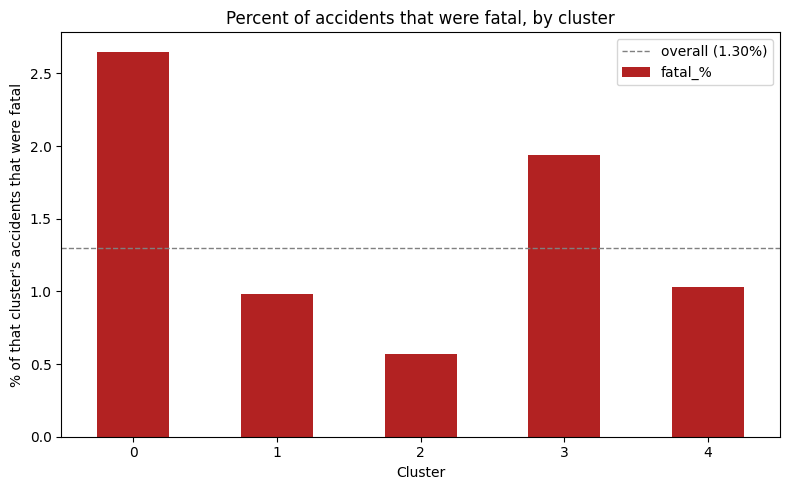

spread between safest and most dangerous cluster: 4.6x


In [22]:
# The headline chart: does the fatal rate actually differ between clusters?
ax = profile['fatal_%'].plot(kind='bar', color='firebrick', figsize=(8, 5))
ax.axhline(overall_fatal, color='grey', ls='--', lw=1, label=f'overall ({overall_fatal:.2f}%)')
plt.title('Percent of accidents that were fatal, by cluster')
plt.xlabel('Cluster'); plt.ylabel('% of that cluster\'s accidents that were fatal')
plt.legend(); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

print('spread between safest and most dangerous cluster: '
      f'{profile["fatal_%"].max() / profile["fatal_%"].min():.1f}x')

### The five accident profiles

| Cluster | Share | Fatal % | What it is |
|---|---|---|---|
| **0** | 22.3% | **2.65%** | **Fast rural roads.** ~62 mph single carriageways, away from junctions, in daylight. Country A- and B-roads. |
| **3** | 8.5% | **1.94%** | **Multi-vehicle collisions.** Averages 3.4 vehicles against 1.7 everywhere else, ~42 mph, away from junctions. |
| **4** | 14.7% | 1.03% | **Urban after dark.** 30 mph town roads at T-junctions, around 7:30pm, street lights lit. |
| **1** | 19.9% | 0.98% | **The morning commute.** Urban 30 mph T-junctions, around 7am, daylight. |
| **2** | 34.6% | **0.57%** | **Urban afternoon.** Same roads as cluster 1 but around 3pm. The largest group and the safest. |

Against an overall rate of 1.30%, the spread from safest to deadliest is **4.6x**.

**The clustering independently found what our EDA found.** Cluster 0 is the standout, and it is
made of exactly the roads Findings 5 and 6 in [`leomary_eda.ipynb`](../notebooks/leomary_eda.ipynb)
identified: fast rural single carriageways where oncoming traffic isn't separated. An algorithm
given nothing but road type, speed, light, weather and time reconstructed that group on its own and
it turned out to be twice as deadly as average. Two different methods reaching the same conclusion
is stronger evidence than either alone.

**Two things the clustering found that the EDA did not.**

*Clusters 1 and 2 are the same roads at different times of day.* Same 30 mph limit, same T-junction
layout, same urban setting, both in daylight — and yet 0.98% fatal in the morning against 0.57% in
the afternoon, nearly double. We had not thought to compare morning against afternoon on identical
roads. We can't explain it from this data; it could be speed, tiredness, sun glare at low angles,
or a different mix of drivers on the road at 7am.

*Cluster 3 is about how many vehicles are involved, not where.* It is the only cluster defined by a
numeric feature rather than a location or a condition — 3.4 vehicles on average against 1.7
everywhere else — and at 1.94% fatal it is the second deadliest. `Number_of_Vehicles` never came up
in our EDA, and this suggests it is worth giving to the supervised model.

## Section 8 — Seeing the structure

Ten features can't be plotted directly, so we used PCA to compress them into two dimensions for a
picture. The axes have no real-world meaning — this is a visual check on whether the clusters
occupy distinct regions, not evidence in its own right.

We plot a 20,000-row subsample so the points stay readable.

We expected the picture to be messier than a textbook example, and it is. One-hot encoded data sits
on the corners of a high-dimensional cube rather than in round clouds, so the groups show up as
overlapping bands rather than separated blobs. That is also why the silhouette scores in Section 5
were low, and it is why we leaned on the fatal-rate evidence instead of the geometry.

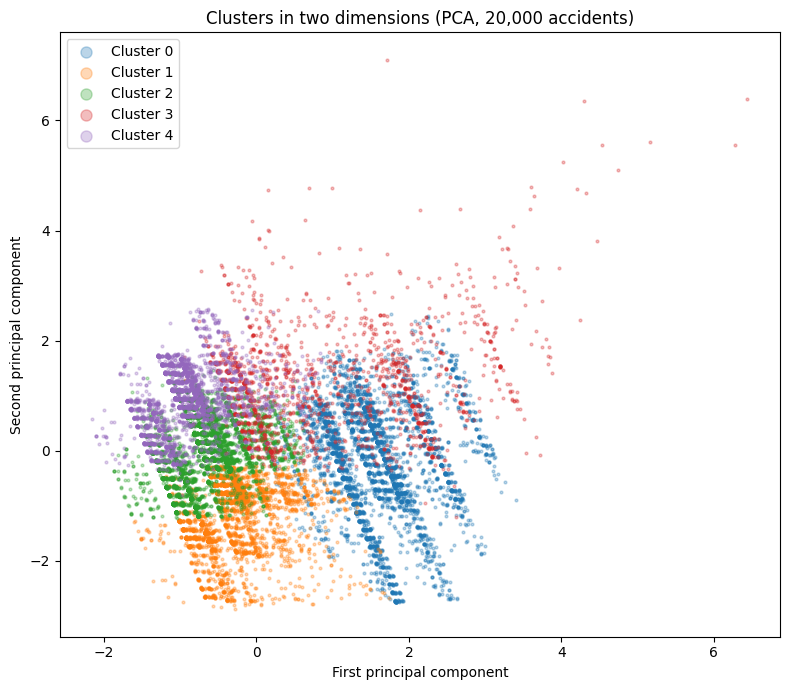

In [23]:
viz = accidents.sample(20_000, random_state=SEED)
X_viz = preprocessor.transform(viz[FEATURES])
if hasattr(X_viz, 'toarray'):
    X_viz = X_viz.toarray()

coords = PCA(n_components=2, random_state=SEED).fit_transform(X_viz)

plt.figure(figsize=(8, 7))
for c in sorted(viz['cluster'].unique()):
    m = viz['cluster'].values == c
    plt.scatter(coords[m, 0], coords[m, 1], s=4, alpha=.3, label=f'Cluster {c}')
plt.title('Clusters in two dimensions (PCA, 20,000 accidents)')
plt.xlabel('First principal component'); plt.ylabel('Second principal component')
plt.legend(markerscale=4); plt.tight_layout(); plt.show()

## Section 9 — Handing the clusters to the supervised model

We export one row per accident with its cluster label. The supervised pair join this on
`Accident_Index`, one-hot the cluster column, and **compare their model with and without it**.

That comparison is what the brief means by using the unsupervised result to inform the supervised
one, and it produces a number rather than an assertion — either the clusters improve recall on
fatal accidents or they don't.

**This file is committed to the repo.** The cleaned CSVs are far too large for GitHub, but this one
is only two columns, and gzipped it comes to about 5.6 MB. So unlike the rest of `data/`, it comes
down with a `git pull` and needs no setup:

```python
clusters = pd.read_csv('../data/preprocessed/accident_clusters.csv.gz')
df = df.merge(clusters, on='Accident_Index', how='left')
```

Because the file carries a label for every accident in both train and test, and because the
clustering never saw `Accident_Severity`, it can be treated as an ordinary engineered feature with
no special handling.

In [24]:
# Compressed: 30 MB of CSV becomes about 5.6 MB, small enough to commit so the
# supervised pair get it with a git pull. pandas reads .gz transparently.
out = accidents[['Accident_Index', 'cluster']].copy()
out.to_csv('../data/preprocessed/accident_clusters.csv.gz', index=False)

print(f'wrote {len(out):,} rows to data/preprocessed/accident_clusters.csv.gz')
print()
print('for the supervised notebook:')
print("  clusters = pd.read_csv('../data/preprocessed/accident_clusters.csv.gz')")
print("  df = df.merge(clusters, on='Accident_Index', how='left')")

wrote 1,991,557 rows to data/preprocessed/accident_clusters.csv.gz

for the supervised notebook:
  clusters = pd.read_csv('../data/preprocessed/accident_clusters.csv.gz')
  df = df.merge(clusters, on='Accident_Index', how='left')


## Section 10 — Findings

**1. UK road accidents fall into five recognisable profiles.** Fast rural roads, multi-vehicle
collisions, urban after dark, the morning commute, and urban afternoons. Every one can be described
in a sentence, which is the main reason we chose five clusters over the two the silhouette score
preferred.

**2. The fatal rate varies 4.6x between them** — 0.57% on urban afternoon roads against 2.65% on
fast rural ones — even though severity played no part in building the clusters. Grouping accidents
purely by their circumstances separates them by outcome, which means the circumstances carry real
information about how badly a crash ends.

**3. The clustering independently confirmed the EDA.** Cluster 0 is the fast rural single
carriageway group that Findings 5 and 6 flagged as the deadliest combination. We did not tell the
algorithm to look for it.

**4. Time of day matters on identical roads.** Clusters 1 and 2 differ only in when they happen —
7am against 3pm on the same urban 30 mph junctions — and the morning is nearly twice as fatal,
0.98% against 0.57%. This was new to us.

**5. Multi-vehicle collisions are their own profile.** Cluster 3 averages 3.4 vehicles and is the
second deadliest at 1.94%. `Number_of_Vehicles` was the only numeric feature strong enough to
define a cluster by itself.

**6. For the supervised model**, we recommend the cluster label be tested as a feature, and that
`Number_of_Vehicles` and `Hour` be included regardless — both proved capable of separating groups
with genuinely different fatal rates.

### Limitations

**KMeans is an imperfect fit for this data.** It assumes clusters are round and roughly equal in
size, and measures distance in a way that suits continuous variables. Nine of our ten features are
categorical, so we one-hot encoded them, which places every accident on the corner of a
high-dimensional cube rather than in a continuous space. The results are interpretable and
reproducible, but `K-Prototypes`, which handles mixed categorical and numeric data natively, would
be the honest next step and we would expect cleaner separation from it.

**We chose k by interpretability, not by metric.** Section 5 sets out our reasoning in full. A
different team could justify k=4 or k=6 from the same plots.

**Cluster sizes are uneven.** Cluster 2 holds 34.6% of accidents and cluster 3 only 8.5%, so the
smaller clusters rest on less data.

**This dataset only contains accidents that happened.** There is no record of the journeys where
nothing went wrong. So a cluster's fatal rate tells us how badly crashes ended in those conditions,
not how likely a crash is in the first place. Cluster 2 being the safest does not mean urban
afternoons are safe to drive in — it means crashes there were less often fatal.

**We dropped 2.7% of rows** for missing features rather than imputing. We think this is
defensible, but those rows may not be missing at random.